## California housing price predictor (Regression)

*The 8 input features are the following:*

**MedInc:** median income in block group

**HouseAge:** median house age in block group

**AveRooms:** average number of rooms per household

**AveBedrms:** average number of bedrooms per household

**Population:** block group population

**AveOccup:** average number of household members

**Latitude:** block group latitude

**Longitude:** block group longitude

*The target variable is a scalar: the median house value for California districts, in dollars.*


Let's load, split and scale the California housing dataset:

In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
housing = fetch_california_housing()

X_train_full,X_test,y_train_full,y_test = train_test_split(housing.data,housing.target,random_state=42)
X_train,X_valid,y_train,y_valid = train_test_split(X_train_full,y_train_full,random_state=42)

In [7]:
X_train_full.shape

(15480, 8)

In [8]:
len(X_test)

5160

In [10]:
len(X_valid)

3870

In [11]:
len(X_train)

11610

In [12]:
# Convert X_train into a DataFrame with attribute names
df_train = pd.DataFrame(X_train,columns=housing.feature_names)

df_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,3.5214,15.0,3.049945,1.106548,1447.0,1.605993,37.63,-122.43
1,5.3275,5.0,6.490060,0.991054,3464.0,3.443340,33.69,-117.39
2,3.1000,29.0,7.542373,1.591525,1328.0,2.250847,38.44,-122.98
3,7.1736,12.0,6.289003,0.997442,1054.0,2.695652,33.55,-117.70
4,2.0549,13.0,5.312457,1.085092,3297.0,2.244384,33.93,-116.93
...,...,...,...,...,...,...,...,...
11605,2.3375,30.0,3.371681,1.008850,840.0,3.716814,34.29,-118.45
11606,4.0977,50.0,4.788009,1.036403,1171.0,2.507495,37.76,-122.48
11607,1.5561,35.0,4.139932,1.220137,1920.0,3.276451,34.11,-117.29
11608,2.1055,52.0,5.178495,1.070968,1361.0,2.926882,36.76,-119.79


Let us standardize the data

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [16]:
np.random.seed(42)
tf.random.set_seed(42)

Let us now define the model architecture

In [17]:
model = keras.models.Sequential([
    keras.layers.Dense(30,activation='relu',input_shape = X_train.shape[1:]),
    keras.layers.Dense(1)
])

model.compile(loss = 'mean_squared_error',optimizer = keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(X_train,y_train,epochs = 20,validation_data = (X_valid,y_valid))

Epoch 1/20


/Users/fahimp/Desktop/Python_Frameworks/neural-network-from-scratch/nn/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - loss: 1.7228 - val_loss: 0.9733
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - loss: 0.7464 - val_loss: 0.6643
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step - loss: 0.6633 - val_loss: 0.6138
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step - loss: 0.6163 - val_loss: 0.5757
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step - loss: 0.5799 - val_loss: 0.5437
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - loss: 0.5508 - val_loss: 0.5169
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step - loss: 0.5270 - val_loss: 0.4949
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - loss: 0.5077 - val_loss: 0.4776
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 392us/step - loss: 0.4918 - val_loss: 0.4648
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 380us/step - loss: 0.4787 - val_loss: 0.4526
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - loss: 0.4678 - val_loss: 0.4417
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 

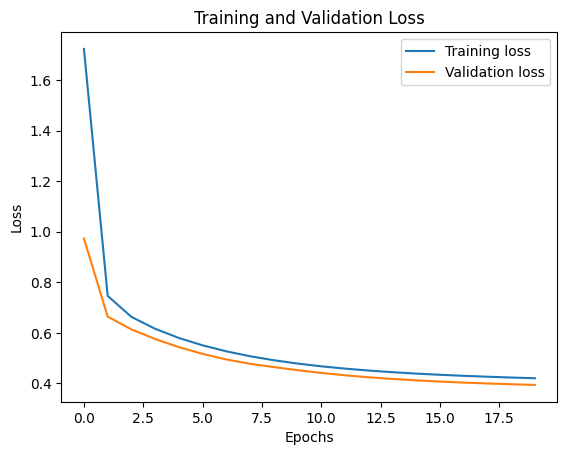

In [20]:
# Plot the loss
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

Let us evaluate the model testing performance

In [21]:
# Evaluate the model on the test set
mse_test = model.evaluate(X_test,y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 301us/step - loss: 0.4170


In [23]:
# Make predictions on new data
X_new = X_test[:3]
y_pred = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [25]:
len(X_new)

3

In [29]:
# Compare predictions with actual values
for i in range(len(X_new)):
    print(f"Sample{i+1}")
    print(f"Predicted: {y_pred[i][0]}")
    print(f"Actual: {y_test[i]}")

Sample1
Predicted: 0.41387003660202026
Actual: 0.477
Sample2
Predicted: 1.543089747428894
Actual: 0.458
Sample3
Predicted: 3.414062023162842
Actual: 5.00001
